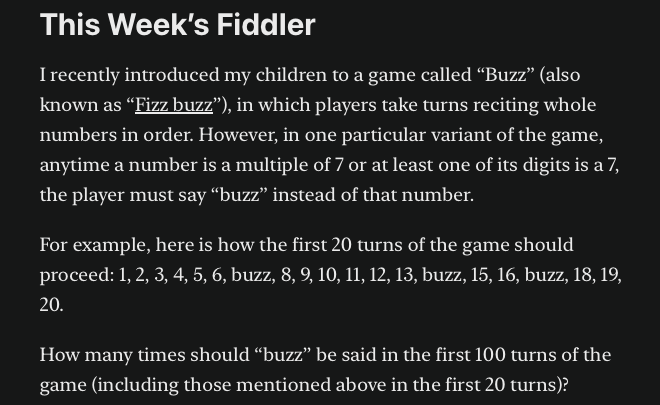


In [108]:
def has_digit(n: int, d: int) -> bool:
    # check if n contains the digit d.
    while n:
        if n % 10 == d:
            return True
        n //= 10
    return False


def buzzable(n: int) -> bool:
    # check if the integer n will produce BUZZ
    return (n % 7) == 0 or has_digit(n, 7)


# Get solution
N = 100
cnt = 0
for n in range(1, N + 1):
    cnt += buzzable(n)

print(f"There were {cnt} for buzzable numbers of value at most {N}")

# you could find this with PIE too.

There were 30 for buzzable numbers of value at most 100


We see there are $\boxed{30}$ numbers below $N = 100$ that _BUZZ_.

---


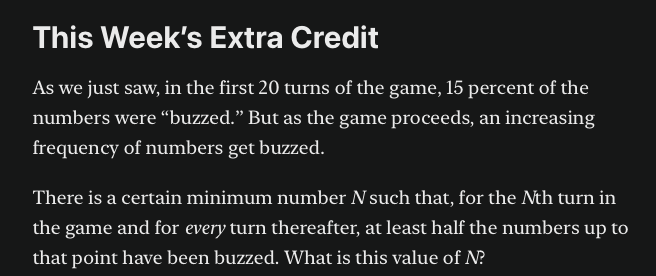


In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np


UPPER = 10**6
cnts = [0] * (UPPER + 1)

for n in range(1, UPPER + 1):
    cnts[n] = cnts[n - 1] + buzzable(n)

ans = -1
for n in range(1, UPPER + 1):
    cnts[n] = cnts[n] / n
    if (
        cnts[n] >= 1 / 2 and cnts[n - 1] < 1 / 2
    ):  # need this to be good and the prev be bad.
        ans = n

print(f"The first value for which the function remains over 1/2 is {ans:,}")

The first value for which the function remains over 1/2 is 708,588


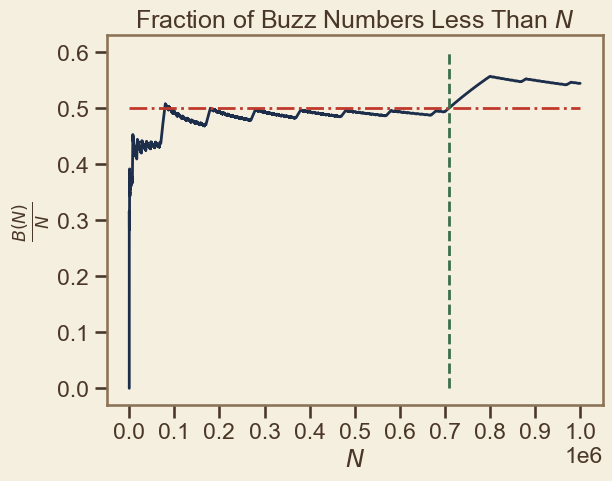

In [130]:
import matplotlib.ticker as ticker
from plot_style import set_style, NAVY, RED

set_style(context="talk")
fig, ax = plt.subplots()

ax.plot(cnts, color=NAVY, linewidth=2)
ax.hlines(0.5, 0, UPPER, linestyles="-.", colors=RED, linewidth=2)

ax.xaxis.set_major_locator(ticker.MultipleLocator(100_000))


ax.vlines(ans, ymin=0, ymax=0.6, colors="#3b6e4a", linewidth=2, linestyles="--")
ax.set_xlabel(r"$N$")
ax.set_ylabel(r"$\frac{B(N)}{N}$")
ax.set_title(r"Fraction of Buzz Numbers Less Than $N$")
plt.show()

For $d$ digit numbers, what fraction of them are _BUZZ_ numbers?

If we just look at the condition that a number contains a 7, what is the probability a number does not have a 7? Let $Z$ be a random number sampled uniformly from all $d$ digit numbers (allowing leading zeros)

It is

$$
\begin{equation}
\Pr[\text{$Z$ has a 7}] = 1 -  \left(1 - 1/10\right)^d
\end{equation}
$$

Note that this is monotonically increasing in $d$ and for $d \approx 6.5$ becomes $1/2$. We would expect to see that at some point in the set of all $d \geq 6$ digit numbers, the _BUZZ_ numbers become the majority of the numbers and eventually the proportion of _BUZZ_ numbers $B(N)$ $\to 1$ as $N \to \infty$. In reality, we would expect on we need fewer than all $d = 6.5$ digit numbers if we also account for the division by $7$ condition.

We see the switch occur in realm of 6 digit numbers as it occurs at $\boxed{N^* = 708,588}$.

Note to show this is the correct answer, we need to prove that there is not a stretch beyond $N^*$ for which the lack of _BUZZ_ numbers causes the overall fraction to drop below $1/2$.


